
# Running Deterministic Inference

Basic deterministic inference workflow.

This example will demonstrate how to run a simple inference workflow to generate a
basic determinstic forecast using one of the built in models of Earth-2 Inference
Studio.

In this example you will learn:

- How to instantiate a built in prognostic model
- Creating a data source and IO object
- Running a simple built in workflow
- Post-processing results


In [ ]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## Set Up
All workflows inside Earth2Studio require constructed components to be
handed to them. In this example, let's take a look at the most basic:
:py:meth:`earth2studio.run.deterministic`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - deterministic start
   :end-before: # sphinx - deterministic end



Thus, we need the following:

- Prognostic Model: Use the built in FourCastNet Model :py:class:`earth2studio.models.px.FCN`.
- Datasource: Pull data from the GFS data api :py:class:`earth2studio.data.GFS`.
- IO Backend: Let's save the outputs into a Zarr store :py:class:`earth2studio.io.ZarrBackend`.



In [11]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # TODO: make common example prep function

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP

# Load the default model package which downloads the check point from NGC
package = DLWP.load_default_package()
model = DLWP.load_model(package)

# Create the data source
data = GFS()

# Create the IO handler, store in memory
io = ZarrBackend()

## Execute the Workflow
With all components initialized, running the workflow is a single line of Python code.
Workflow will return the provided IO object back to the user, which can be used to
then post process. Some have additional APIs that can be handy for post-processing or
saving to file. Check the API docs for more information.

For the forecast we will predict for two days (these will get executed as a batch) for
20 forecast steps which is 5 days.



In [12]:
import earth2studio.run as run

nsteps = 20
io = run.deterministic(["2026-04-23"], nsteps, model, data, io)

print(io.root.tree())

2026-04-24 11:21:29.098 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-24 11:21:29.098 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 110.07it/s]


2026-04-24 11:21:29.141 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 426917829-1198860
2026-04-24 11:21:29.150 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 259102372-817528
2026-04-24 11:21:29.160 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 302522544-868743
2026-04-24 11:21:29.169 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 337187421-847282
2026-04-24 11:21:29.178 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 414630280-892684
2026-04-24 11:21:29.186 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 117.85it/s]

2026-04-24 11:21:29.235 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 413943594-876479
2026-04-24 11:21:29.244 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 302420854-863554
2026-04-24 11:21:29.252 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 214783953-731002
2026-04-24 11:21:29.261 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 403353752-999414
2026-04-24 11:21:29.269 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 425763906-1197334
2026-04-24 11:21:29.278 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

2026-04-24 11:21:29.307 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-24 11:21:29.317 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 21/21 [00:02<00:00,  7.76it/s]

2026-04-24 11:21:32.025 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (21,) timedelta64[h]
├── lon (1440,) float64
├── t2m (1, 21, 721, 1440) float32
├── t850 (1, 21, 721, 1440) float32
├── tcwv (1, 21, 721, 1440) float32
├── time (1,) datetime64[ns]
├── z1000 (1, 21, 721, 1440) float32
├── z300 (1, 21, 721, 1440) float32
├── z500 (1, 21, 721, 1440) float32
└── z700 (1, 21, 721, 1440) float32



## Post Processing
The last step is to post process our results. Cartopy is a great library for plotting
fields on projections of a sphere. Here we will just plot the temperature at 2 meters
(t2m) 1 day into the forecast.

Notice that the Zarr IO function has additional APIs to interact with the stored data.



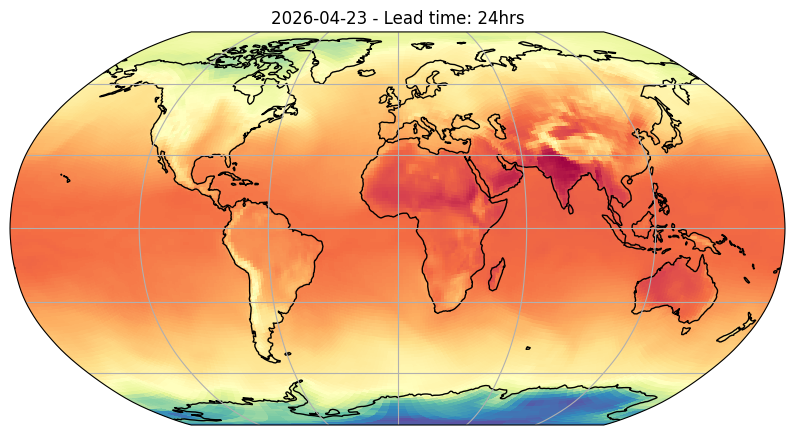

In [13]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = "2026-04-23"
variable = "t2m"
step = 4  # lead time = 24 hrs

plt.close("all")
# Create a Robinson projection
projection = ccrs.Robinson()

# Create a figure and axes with the specified projection
fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))

# Plot the field using pcolormesh
im = ax.pcolormesh(
    io["lon"][:],
    io["lat"][:],
    io[variable][0, step],
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
)

# Set title
ax.set_title(f"{forecast} - Lead time: {6*step}hrs")

# Add coastlines and gridlines
ax.coastlines()
ax.gridlines()
plt.savefig("outputs/01_t2m_prediction.jpg")